## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import shap
shap.initjs()  # enables interactive plots in Jupyter

# ── PATHS ────────────────────────────────────────────────────────────────────
BASE          = r"D:\Griffith College Docs year 2\01 Dissertation"
FEATURES_PATH = os.path.join(BASE, "merged-datasets", "features_dataset.parquet")
MODELS_DIR    = os.path.join(BASE, "Models")
XGB_PATH      = os.path.join(MODELS_DIR, "xgboost.pkl")
SHAP_OUT      = os.path.join(MODELS_DIR, "shap_values.npy")

print('All imports successful ✅')
print(f'SHAP version: {shap.__version__}')

All imports successful ✅
SHAP version: 0.52.0


## 2. Load Model and Data

In [2]:
FEATURE_COLS = [
    'bikes_min', 'docks_min', 'capacity', 'reading_count',
    'occupancy_ratio', 'docks_occupancy_ratio',
    'bikes_lag_1h', 'bikes_lag_2h', 'bikes_lag_3h',
    'bikes_lag_4h', 'bikes_lag_5h',
    'bikes_lag_6h', 'bikes_lag_12h', 'bikes_lag_24h',
    'docks_lag_1h', 'docks_lag_2h', 'docks_lag_3h',
    'rolling_mean_3h', 'rolling_mean_6h', 'rolling_std_3h',
    'bikes_change_1h', 'bikes_change_3h', 'occupancy_lag_1h',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'is_public_holiday', 'is_working_day',
    'rain', 'temp', 'rhum', 'msl', 'wetb', 'dewpt', 'vappr',
    'is_imputed'
]
TARGET = 'will_stockout_1h'

# ── Load XGBoost model ───────────────────────────────────────────────────────
print('Loading XGBoost model...')
with open(XGB_PATH, 'rb') as f:
    model = pickle.load(f)
print(f'Model loaded ✅  Best iteration: {model.best_iteration}')


print('\nLoading features dataset...')
cols_to_load = ['datetime_hour', 'station_id', 'name'] + FEATURE_COLS + [TARGET]
df = pd.read_parquet(FEATURES_PATH, columns=cols_to_load)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

# Validation set: 2025 data
val = df[
    (df['datetime_hour'] > '2024-12-31 23:00:00') &
    (df['datetime_hour'] <= '2025-12-31 23:00:00')
].copy()

print(f'Validation set rows : {len(val):,}')
print(f'Stock-out rate      : {val[TARGET].mean()*100:.2f}%')

# Sample for SHAP : stratified to keep stock-out proportion
# 5,000 rows is standard for SHAP research papers
np.random.seed(42)
pos_idx = val[val[TARGET]==1].sample(n=2500, random_state=42).index # Radnomly picks rows that stocked-out
neg_idx = val[val[TARGET]==0].sample(n=2500, random_state=42).index # Radnomly picks rows that did not stocked-out
shap_sample = val.loc[pos_idx.union(neg_idx)].sample(frac=1, random_state=42)

X_shap = shap_sample[FEATURE_COLS].to_numpy(dtype='float32') # an array of size (5000, 37) containing feature values for all 37 sample rows
y_shap = shap_sample[TARGET].values # A 1d array of 5000 actual target values

print(f'\nSHAP sample: {len(X_shap):,} rows (2,500 stock-out + 2,500 normal)')
print(f'Stock-out rate in sample: {y_shap.mean()*100:.1f}%')

Loading XGBoost model...
Model loaded ✅  Best iteration: 999

Loading features dataset...
Validation set rows : 981,867
Stock-out rate      : 15.26%

SHAP sample: 5,000 rows (2,500 stock-out + 2,500 normal)
Stock-out rate in sample: 50.0%


## 3. Compute SHAP Values

SHAP TreeExplainer is used for XGBoost it is exact and fast for tree models.
Each SHAP value represents how much a feature pushed a prediction
above or below the average prediction.

In [3]:
print('Computing SHAP values...')
print('(TreeExplainer is fast for XGBoost : typically 1-3 minutes)')

# creates the tree explainer model from XGBoost model and then computes shap values for all 5000 rows
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP values shape : {shap_values.shape}')
print(f'Expected value    : {explainer.expected_value:.4f}')
print(f'(Base rate : average prediction across all samples)')

# Save for dashboard use as a .npy binary file
np.save(SHAP_OUT, shap_values)
print(f'\nSHAP values saved to: {SHAP_OUT}')

Computing SHAP values...
(TreeExplainer is fast for XGBoost : typically 1-3 minutes)
SHAP values shape : (5000, 37)
Expected value    : 0.0009
(Base rate : average prediction across all samples)

SHAP values saved to: D:\Griffith College Docs year 2\01 Dissertation\Models\shap_values.npy


## 4. Global Feature Importance

Mean absolute SHAP value per feature across all 5,000 samples.
Shows which features matter most to the model overall.

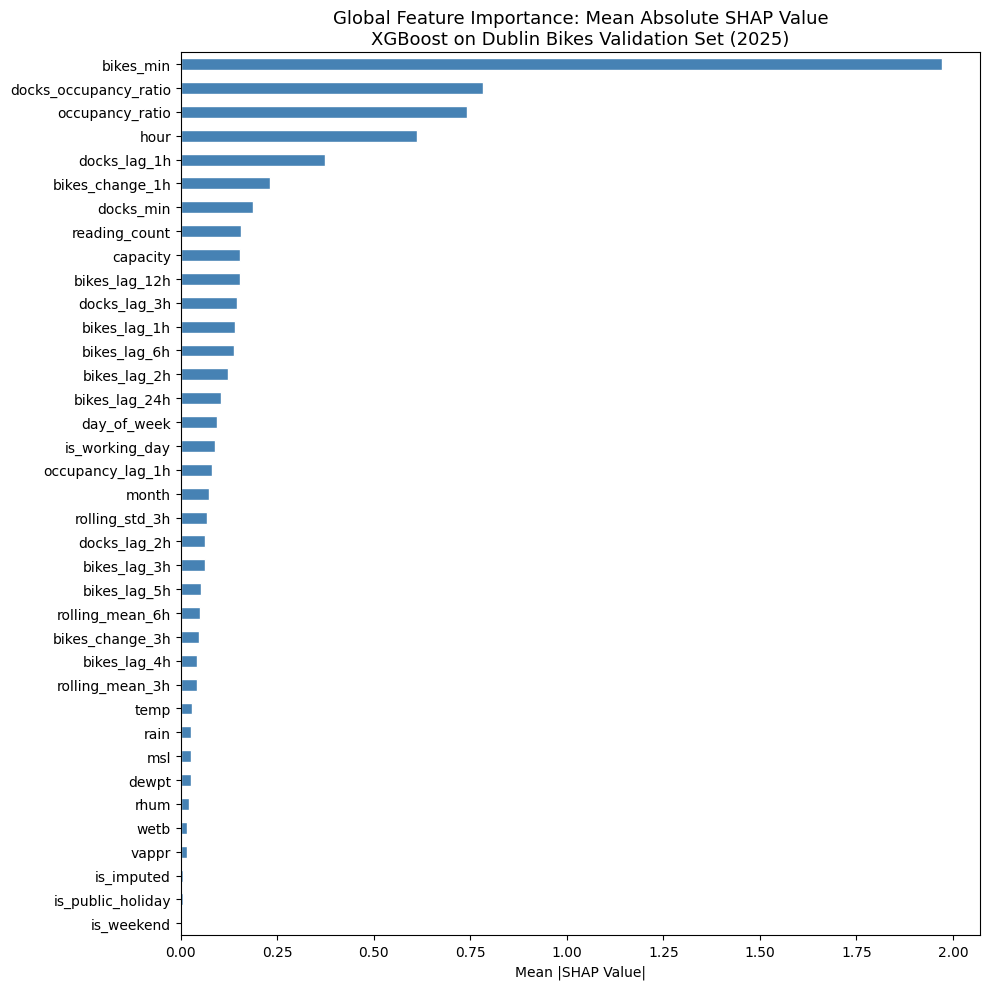

Top 10 most important features (SHAP):
   1. bikes_min                 1.9714
   2. docks_occupancy_ratio     0.7839
   3. occupancy_ratio           0.7410
   4. hour                      0.6114
   5. docks_lag_1h              0.3724
   6. bikes_change_1h           0.2306
   7. docks_min                 0.1880
   8. reading_count             0.1547
   9. capacity                  0.1542
  10. bikes_lag_12h             0.1530


In [4]:
# takes the absolute value for each shap value and averages across all 5,000 rows, then wraps the 37 features in a pandas series with feature names as index.
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS)
feat_importance = feat_importance.sort_values(ascending=False)

# Plot a bar-graph that will display the absolute shap values for each column
plt.figure(figsize=(10, 10))
feat_importance.sort_values().plot(
    kind='barh', color='steelblue', edgecolor='white')
plt.title('Global Feature Importance: Mean Absolute SHAP Value\n'
          'XGBoost on Dublin Bikes Validation Set (2025)', fontsize=13)
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'shap_global_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#Prints the top 10 most important features
print('Top 10 most important features (SHAP):')
for i, (feat, val) in enumerate(feat_importance.head(10).items(), 1):
    print(f'  {i:>2}. {feat:<25} {val:.4f}')

## 5. SHAP Summary Plot (Beeswarm)

Shows both feature importance AND direction of effect.
- Red dots = high feature value
- Blue dots = low feature value
- Right side = pushes toward stock-out prediction
- Left side = pushes away from stock-out prediction

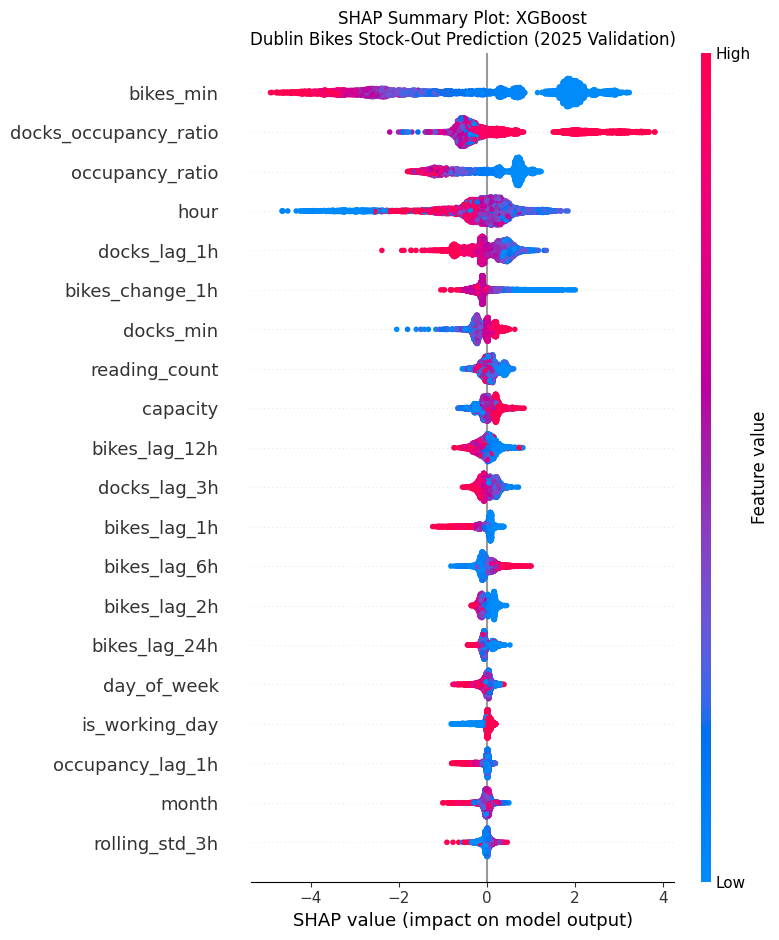

How to read this chart:
  Each dot is one observation from the 5,000-row sample
  Colour = feature value (red=high, blue=low)
  Position = SHAP impact (right=pushes toward stock-out, left=away from it)
  Spread = how consistently the feature affects predictions


In [5]:
# Generates a image using SHAP's built-in beeswarm plot showing both importance AND direction of effect for each feature
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURE_COLS,
    show=False,
    max_display=20
)
plt.title('SHAP Summary Plot: XGBoost\n'
          'Dublin Bikes Stock-Out Prediction (2025 Validation)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'shap_summary_beeswarm.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('How to read this chart:')
print('  Each dot is one observation from the 5,000-row sample')
print('  Colour = feature value (red=high, blue=low)')
print('  Position = SHAP impact (right=pushes toward stock-out, left=away from it)')
print('  Spread = how consistently the feature affects predictions')

## 6. SHAP Dependence Plots : Key Features

Shows exactly how each feature value affects the stock-out prediction.
Reveals non-linear patterns the model has learned.

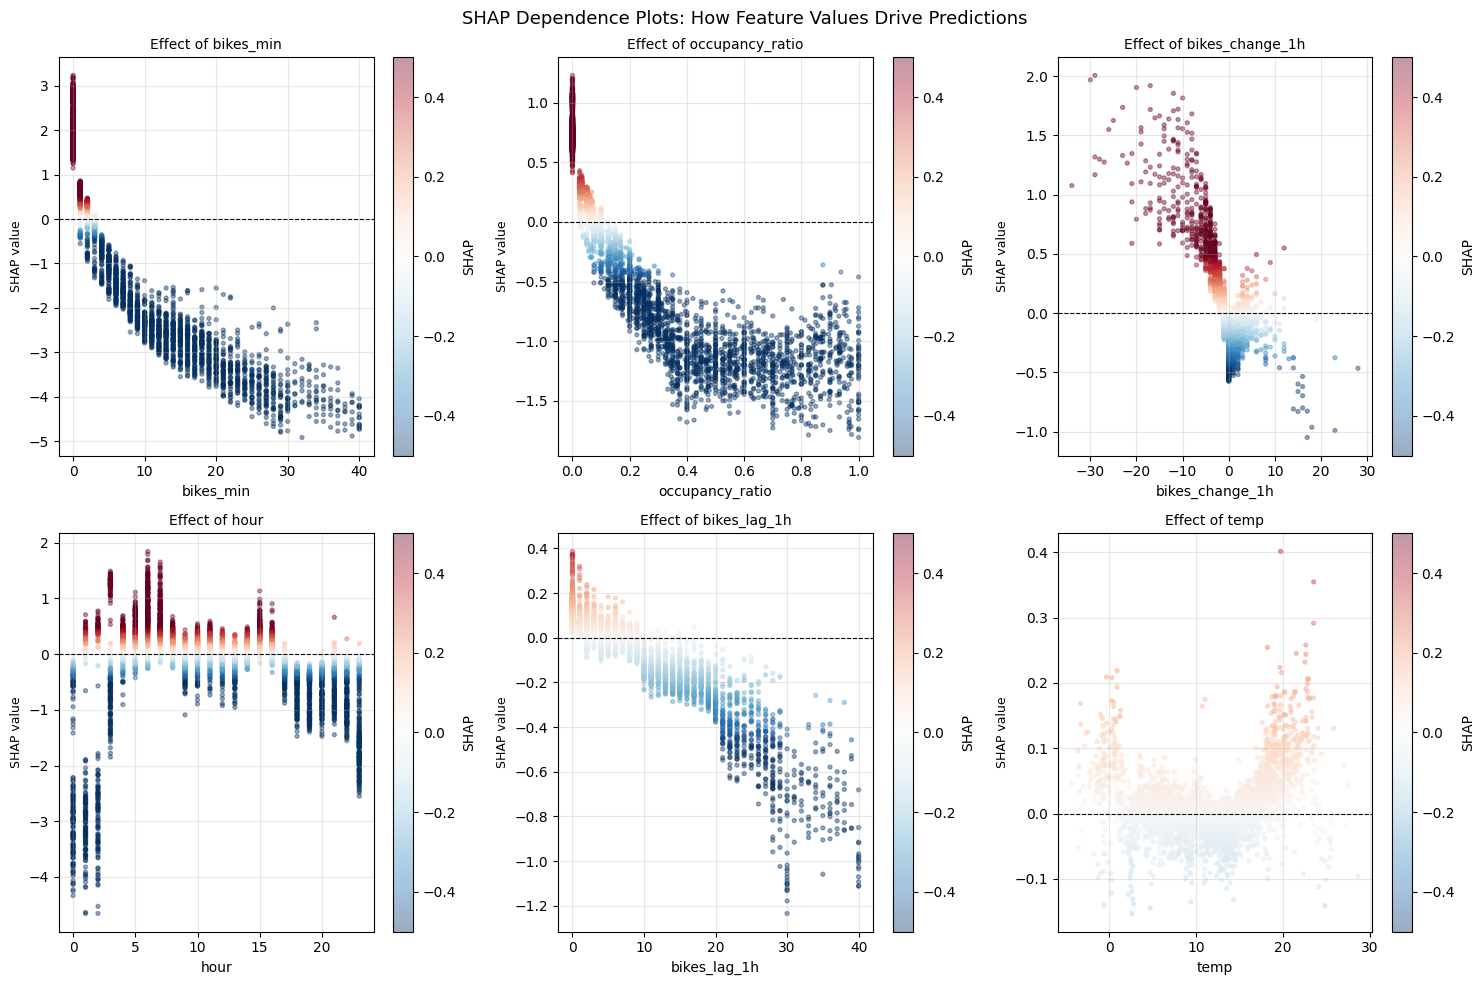

In [6]:
# Creates a 2x3 grid of 6 subplots that converts the 2D array of axes  into a 1d list so they can iterated with a simple loop
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()


key_features = [
    'bikes_min', 'occupancy_ratio', 'bikes_change_1h',
    'hour', 'bikes_lag_1h', 'temp'
]

# Dictionary mapping features names to its position index in feature_cols
feat_idx = {f: i for i, f in enumerate(FEATURE_COLS)}

for ax, feat in zip(axes, key_features):
    idx = feat_idx[feat]
    x_vals = X_shap[:, idx] # 5000 actual feature values for this feature
    s_vals = shap_values[:, idx] # 5000 shap values for this feature

    # Draws a scatterplot
    sc = ax.scatter(x_vals, s_vals, c=s_vals, cmap='RdBu_r', alpha=0.4, s=8, vmin=-0.5, vmax=0.5) # s_vals colors each dot with shap value, alpha has 40% opacity, s is the dot size color scale range
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--') # Horizontal dashed line
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=9)
    ax.set_title(f'Effect of {feat}', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='SHAP')

plt.suptitle('SHAP Dependence Plots: How Feature Values Drive Predictions',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'shap_dependence_plots.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Individual Prediction Explanation : Stock-Out Case

Picks one real stock-out event and explains exactly why the model flagged it.
This is the most powerful output for the dissertation and the dashboard.

STOCK-OUT PREDICTION EXPLAINED
Row index        : 1
Predicted prob   : 1.000 (100.0% stock-out risk)
Actual outcome   : STOCK-OUT
Base rate (avg)  : 0.001

Top features pushing TOWARD stock-out (positive SHAP):
  docks_occupancy_ratio     value=    1.00  SHAP=+2.9716  → RISK ↑
  bikes_min                 value=    0.00  SHAP=+2.8564  → RISK ↑
  occupancy_ratio           value=    0.00  SHAP=+1.0497  → RISK ↑
  hour                      value=    1.00  SHAP=+0.3653  → RISK ↑
  reading_count             value=    6.00  SHAP=+0.2776  → RISK ↑
  bikes_lag_2h              value=    0.00  SHAP=+0.2320  → RISK ↑
  bikes_lag_1h              value=    0.00  SHAP=+0.1620  → RISK ↑
  bikes_lag_4h              value=    0.00  SHAP=+0.1355  → RISK ↑

Top features pushing AWAY from stock-out (negative SHAP):
  bikes_change_1h           value=    0.00  SHAP=-0.1011
  day_of_week               value=    4.00  SHAP=-0.0851
  docks_min                 value=   25.00  SHAP=-0.0599
  bikes_lag_24h        

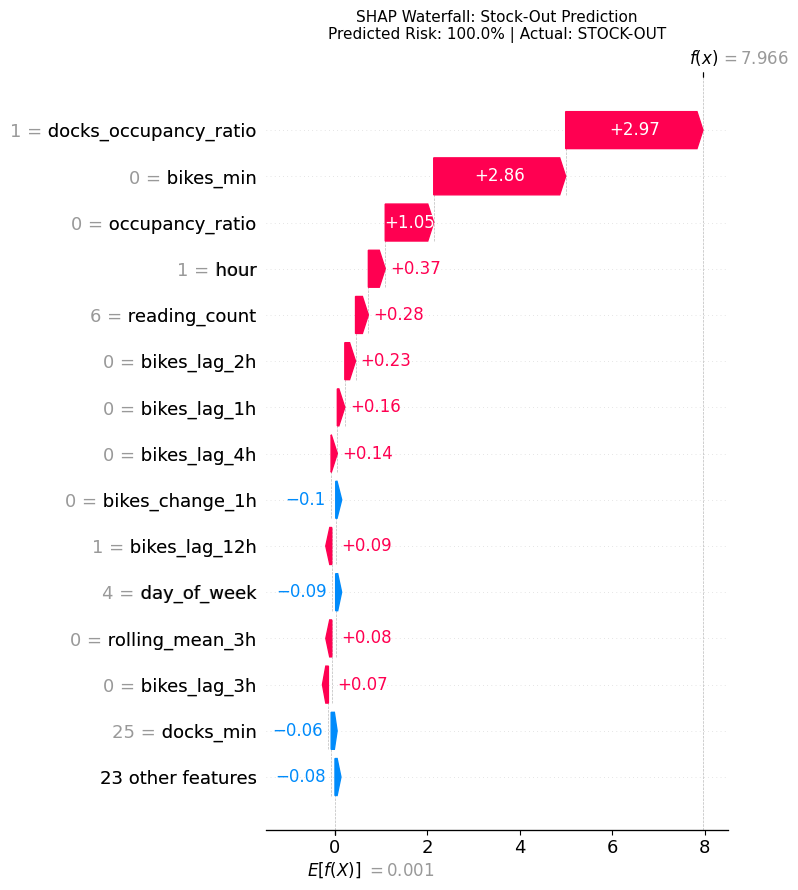

In [7]:
# Find a high-confidence correct stock-out prediction
probas = model.predict_proba(X_shap)[:, 1] # runs prediction on all 5000 rows and extract stock-out probability for each
stockout_mask = y_shap == 1 # true for every row that actually stock-out
high_conf_stockouts = np.where(stockout_mask & (probas > 0.85))[0]

# takes the first high-confidence correct stock-out, if not Fallbacks to first actual stock-out regardless of confidence
if len(high_conf_stockouts) > 0:
    idx = high_conf_stockouts[0]
else:
    idx = np.where(stockout_mask)[0][0]

print('STOCK-OUT PREDICTION EXPLAINED')
print(f'Row index        : {idx}')
print(f'Predicted prob   : {probas[idx]:.3f} ({probas[idx]*100:.1f}% stock-out risk)')
print(f'Actual outcome   : {"STOCK-OUT" if y_shap[idx]==1 else "SAFE"}')
print(f'Base rate (avg)  : {explainer.expected_value:.3f}')
print()

# Show the actual feature values for this row
row_features = pd.Series(X_shap[idx], index=FEATURE_COLS)
row_shap     = pd.Series(shap_values[idx], index=FEATURE_COLS)

# sorts SHAP values from highest to lowest and prints the top 8
print('Top features pushing TOWARD stock-out (positive SHAP):')
top_pos = row_shap.sort_values(ascending=False).head(8)
for feat, sv in top_pos.items():
    fval = row_features[feat]
    direction = '→ RISK ↑' if sv > 0 else '→ RISK ↓'
    print(f'  {feat:<25} value={fval:>8.2f}  SHAP={sv:>+.4f}  {direction}')

print('\nTop features pushing AWAY from stock-out (negative SHAP):')
top_neg = row_shap.sort_values(ascending=True).head(5)
for feat, sv in top_neg.items():
    fval = row_features[feat]
    print(f'  {feat:<25} value={fval:>8.2f}  SHAP={sv:>+.4f}')

# Waterfall chart
shap_exp = shap.Explanation(
    values=shap_values[idx], # the 37 shap values for this one row.
    base_values=explainer.expected_value, 
    data=X_shap[idx],
    feature_names=FEATURE_COLS
)
plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall: Stock-Out Prediction\n'
          f'Predicted Risk: {probas[idx]*100:.1f}% | Actual: STOCK-OUT', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'shap_waterfall_stockout.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Individual Prediction Explanation : Safe Case

Picks one genuinely safe station-hour and explains why the model said it was safe.
Contrasting a safe prediction with a stock-out prediction shows the model
is reasoning correctly about both classes.

SAFE PREDICTION EXPLAINED
Predicted prob   : 0.000 (0.0% stock-out risk)
Actual outcome   : SAFE


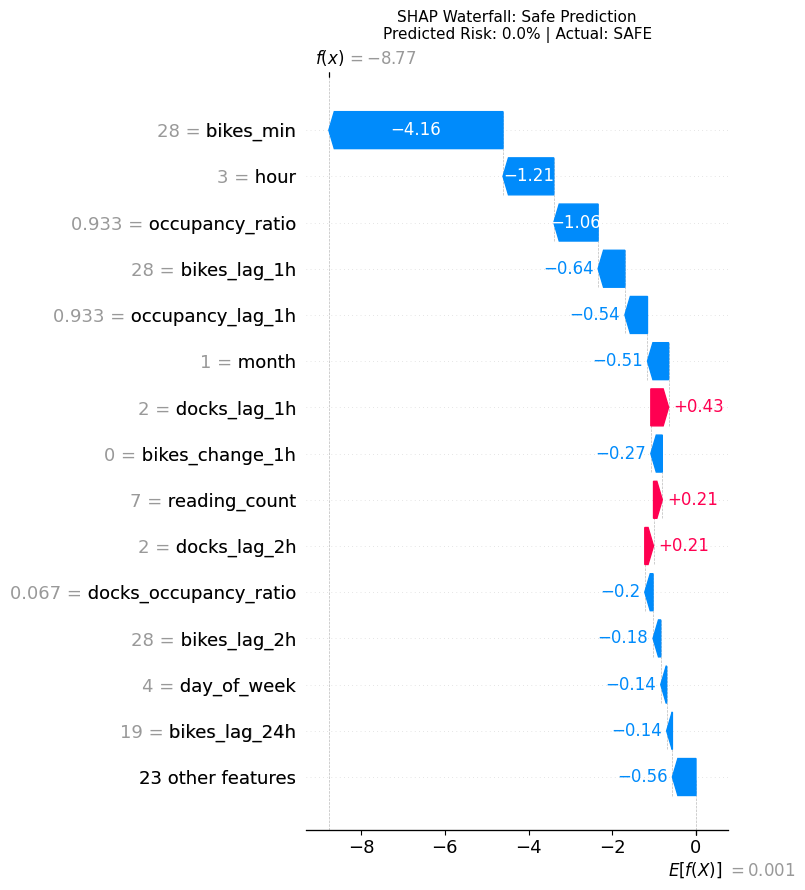


Key feature values for this safe station-hour:
  bikes_min                 : 28.00
  occupancy_ratio           : 0.93
  bikes_change_1h           : 0.00
  hour                      : 3.00
  is_working_day            : 1.00


In [8]:
# Same pattern, but reversed
safe_mask = y_shap == 0
high_conf_safe = np.where(safe_mask & (probas < 0.1))[0]

# takes the first high-confidence correct safe prediction
if len(high_conf_safe) > 0:
    idx_safe = high_conf_safe[0]
else:
    idx_safe = np.where(safe_mask)[0][0]

print('SAFE PREDICTION EXPLAINED')
print(f'Predicted prob   : {probas[idx_safe]:.3f} ({probas[idx_safe]*100:.1f}% stock-out risk)')
print(f'Actual outcome   : {"STOCK-OUT" if y_shap[idx_safe]==1 else "SAFE"}')

shap_exp_safe = shap.Explanation(
    values=shap_values[idx_safe],
    base_values=explainer.expected_value,
    data=X_shap[idx_safe],
    feature_names=FEATURE_COLS
)
plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_exp_safe, max_display=15, show=False)
plt.title(f'SHAP Waterfall: Safe Prediction\n'
          f'Predicted Risk: {probas[idx_safe]*100:.1f}% | Actual: SAFE', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'shap_waterfall_safe.png'),
            dpi=150, bbox_inches='tight')
plt.show()

row_safe = pd.Series(X_shap[idx_safe], index=FEATURE_COLS)
print('\nKey feature values for this safe station-hour:')

# prints the five key feature values for the safe station-hourd
for feat in ['bikes_min','occupancy_ratio','bikes_change_1h','hour','is_working_day']:
    print(f'  {feat:<25} : {row_safe[feat]:.2f}')

## 9. Station-Level Risk Profile

Shows which stations have the highest average SHAP-predicted risk.
Identifies the most problematic stations in the network.

Top 15 highest-risk stations (by average predicted probability):
                        name  avg_risk_pct  actual_rate_pct  n_obs
             HARDWICKE PLACE     88.099998             83.5     97
          ECCLES STREET EAST     82.300003             78.3     83
        PARNELL SQUARE NORTH     81.800003             81.4     86
            HARDWICKE STREET     78.900002             78.9     71
           JAMES STREET EAST     78.699997             79.7     59
        DENMARK STREET GREAT     77.599998             74.6     67
       WILTON TERRACE (PARK)     77.199997             76.8     56
               ECCLES STREET     73.300003             72.7     55
     FITZWILLIAM SQUARE EAST     72.500000             66.2     71
   ST. STEPHEN'S GREEN SOUTH     72.099998             68.6     51
           EARLSFORT TERRACE     72.099998             68.0     50
          CHRISTCHURCH PLACE     72.000000             72.9     48
GRANGEGORMAN LOWER (CENTRAL)     71.400002             73.8     

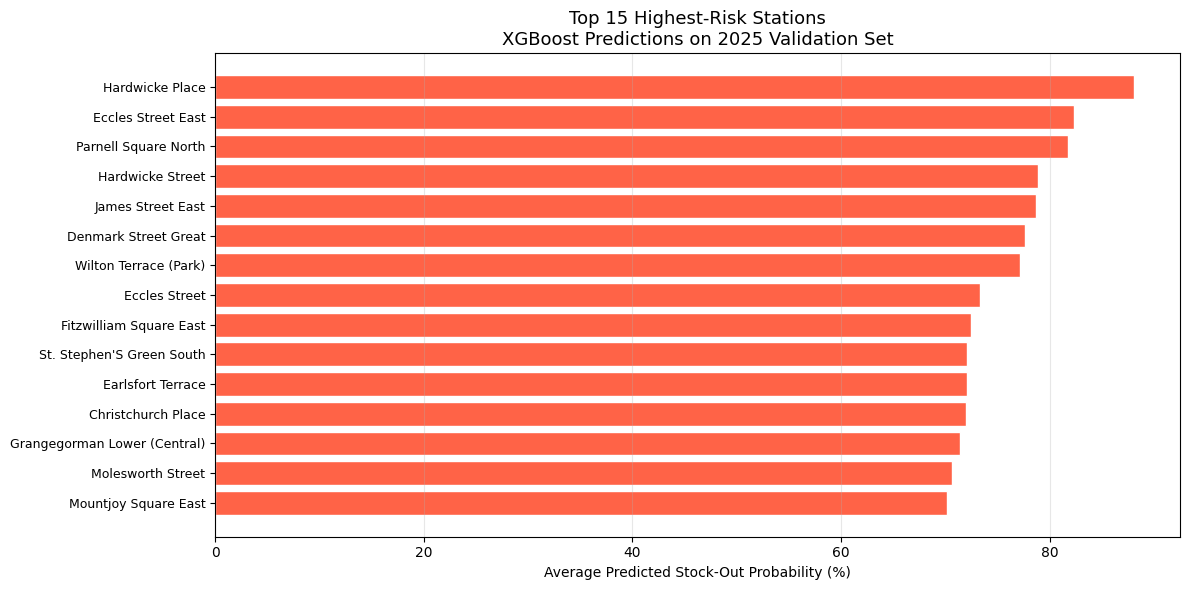

In [9]:
# Add predicted probabilities to the SHAP sample
shap_df = shap_sample[['station_id','name','datetime_hour',TARGET]].copy().reset_index(drop=True)
shap_df['predicted_prob'] = probas
shap_df['mean_abs_shap']  = np.abs(shap_values).mean(axis=1)

# Average predicted risk per station
station_risk = shap_df.groupby(['station_id','name']).agg(
    avg_risk      = ('predicted_prob', 'mean'),
    actual_rate   = (TARGET, 'mean'),
    n_obs         = ('predicted_prob', 'count')
).reset_index().sort_values('avg_risk', ascending=False)

# Converts voth metrics from fractions to percentages rounded to one decimal place
station_risk['avg_risk_pct']  = (station_risk['avg_risk']  * 100).round(1)
station_risk['actual_rate_pct']= (station_risk['actual_rate'] * 100).round(1)

print('Top 15 highest-risk stations (by average predicted probability):')
print(station_risk[['name','avg_risk_pct','actual_rate_pct','n_obs']].head(15).to_string(index=False))

# generates a horizontal bar graph that shows stations with highest risk profile
plt.figure(figsize=(12, 6))
top15 = station_risk.head(15)
plt.barh(range(15), top15['avg_risk_pct'].values, color='tomato', edgecolor='white')
plt.yticks(range(15), top15['name'].str.title().values, fontsize=9)
plt.xlabel('Average Predicted Stock-Out Probability (%)')
plt.title('Top 15 Highest-Risk Stations\nXGBoost Predictions on 2025 Validation Set', fontsize=13)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'shap_station_risk.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 10. SHAP Values by Hour of Day

Shows how the time of day drives stock-out predictions.
Reveals the commuter rush hour pattern through the model's lens.

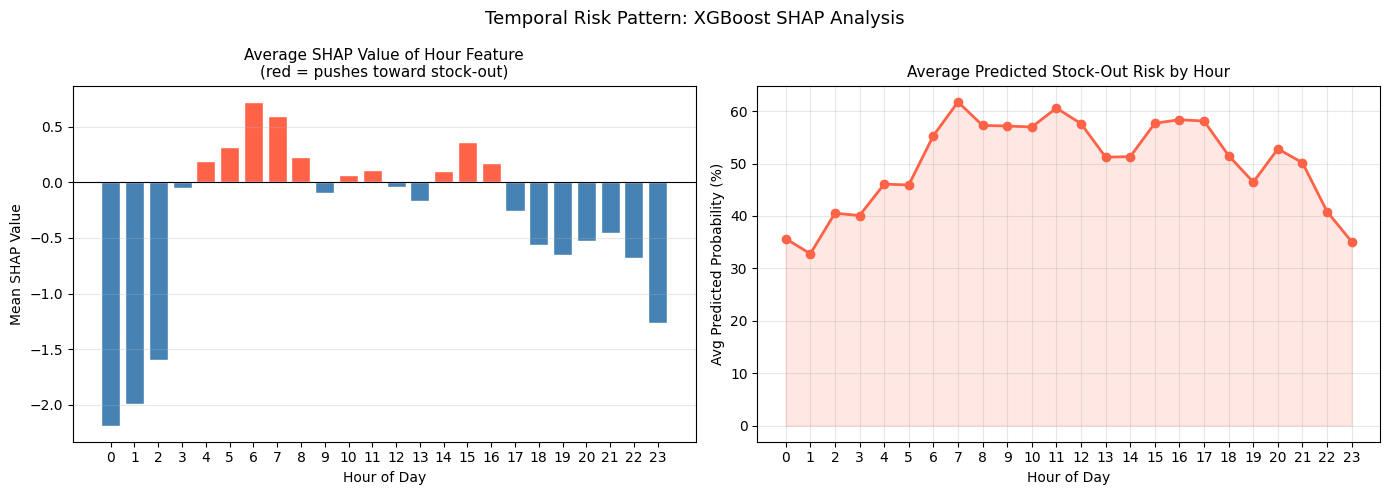

In [10]:
# Average SHAP value for the 'hour' feature by hour of day
hour_idx = FEATURE_COLS.index('hour')
shap_df['hour']       = X_shap[:, FEATURE_COLS.index('hour')]
shap_df['shap_hour']  = shap_values[:, hour_idx]
shap_df['shap_bikes'] = shap_values[:, FEATURE_COLS.index('bikes_min')]
shap_df['shap_occ']   = shap_values[:, FEATURE_COLS.index('occupancy_ratio')]

# groups all 5000 rows by hour  of day and computes three averages per hour
hourly_shap = shap_df.groupby('hour').agg(
    mean_shap_hour  = ('shap_hour',  'mean'),
    mean_shap_bikes = ('shap_bikes', 'mean'),
    mean_risk       = ('predicted_prob', 'mean')
).reset_index()

# Plot 2 figures on two diff axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly SHAP showing average SHAP value at that hour
colors = ['tomato' if v > 0 else 'steelblue' for v in hourly_shap['mean_shap_hour']]
axes[0].bar(hourly_shap['hour'], hourly_shap['mean_shap_hour'], color=colors, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Average SHAP Value of Hour Feature\n(red = pushes toward stock-out)', fontsize=11)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean SHAP Value')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3, axis='y')

# Average predicted risk by hour showing risk percentage on that hour of the day
axes[1].plot(hourly_shap['hour'], hourly_shap['mean_risk']*100,
             marker='o', color='tomato', linewidth=2)
axes[1].fill_between(hourly_shap['hour'], hourly_shap['mean_risk']*100,
                     alpha=0.15, color='tomato')
axes[1].set_title('Average Predicted Stock-Out Risk by Hour', fontsize=11)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Predicted Probability (%)')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3)

plt.suptitle('Temporal Risk Pattern: XGBoost SHAP Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'shap_hourly_pattern.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 11. Save SHAP Values and Summary

In [11]:
print('=== SHAP ANALYSIS COMPLETE ===')
print(f'\nSHAP values saved : {SHAP_OUT}')
print('\nPlots saved to Models folder:')
plot_files = [
    'shap_global_importance.png',
    'shap_summary_beeswarm.png',
    'shap_dependence_plots.png',
    'shap_waterfall_stockout.png',
    'shap_waterfall_safe.png',
    'shap_station_risk.png',
    'shap_hourly_pattern.png'
]
for fname in plot_files:
    fpath = os.path.join(MODELS_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)/1e3
        print(f'  ✅ {fname:<45} {size:.0f} KB')
    else:
        print(f'  ❌ {fname} : not found')

top3 = feat_importance.head(3)
print('Top 3 features driving stock-out predictions:')
for i, (feat, val) in enumerate(top3.items(), 1):
    print(f'  {i}. {feat} (mean |SHAP| = {val:.4f})')

print(f'\nBase rate (average model output): {explainer.expected_value:.4f}')

=== SHAP ANALYSIS COMPLETE ===

SHAP values saved : D:\Griffith College Docs year 2\01 Dissertation\Models\shap_values.npy

Plots saved to Models folder:
  ✅ shap_global_importance.png                    117 KB
  ✅ shap_summary_beeswarm.png                     214 KB
  ✅ shap_dependence_plots.png                     664 KB
  ✅ shap_waterfall_stockout.png                   127 KB
  ✅ shap_waterfall_safe.png                       126 KB
  ✅ shap_station_risk.png                         81 KB
  ✅ shap_hourly_pattern.png                       85 KB
Top 3 features driving stock-out predictions:
  1. bikes_min (mean |SHAP| = 1.9714)
  2. docks_occupancy_ratio (mean |SHAP| = 0.7839)
  3. occupancy_ratio (mean |SHAP| = 0.7410)

Base rate (average model output): 0.0009
